# Experiment 2 — The Superstar (Covariate Imbalance)

**Goal:** Show that having one dominant covariate significantly extends the LOO bound's
protective range compared to the equal-strength baseline (Experiment 1).

**Setup**
- $D^* = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$, $\quad D = \mathbf{1}[D^* > 0]$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.9,\, 0.2,\, 0.2,\, 0.1,\, 0.1]$ — one dominant
  predictor mimics real data where one variable (e.g. income) dwarfs the rest.
  This widens the LOO bound (anchored to the 0.9 superstar) and creates a smooth, gradual
  cliff instead of the sharp drop seen in the baseline.
- Multiplier $m$ sweeps from $0.5$ to $2.0$ (50 steps):
  $\beta_{DA} = \beta_{YA} = 0.5m$

**Benchmark:** LOO (leave-one-out) — for each observed $X_j$, treat it as the mock omitted
confounder and compute bound $B_j$.

$B_{\max} = \max_j B_j$.

**Coverage metric:** across 250 Monte Carlo trials per multiplier,
$$\text{Coverage}(m) = \Pr\bigl(|\hat{\tau}_{\text{short}} - \tau_{\text{true}}| \le B_{\max}\bigr)$$

Compare the cliff location here to Experiment 1 (baseline) to quantify the protective
effect of having one highly predictive covariate acting as an anchor.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dgp import DGPConfig, generate_data
from loo_benchmark import loo_benchmark
from ovb_formula import compute_RV
from robustness_plot import plot_robustness_contour

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [2]:
tau_true   = 1.0
n_trials   = 250

beta_dx    = (0.9, 0.2, 0.2, 0.1, 0.1)
beta_yx    = (0.9, 0.2, 0.2, 0.1, 0.1)

multipliers = np.linspace(0.5, 2.0, 50)

coverage        = []
mean_ovb        = []
mean_Bmax       = []
mean_RV         = []
mean_rho        = []     # absolute tightness: |OVB| / B_max
mean_signed_rho = []     # signed tightness: (τ_short − τ_true) / B_max
p10_rho         = []
p90_rho         = []
p10_signed_rho  = []
p90_signed_rho  = []
mean_sig_slack  = []     # practitioner headroom — NOT a validity diagnostic
mean_r2_ax      = []
last_trial_data = {}

for m_idx, multiplier in enumerate(multipliers):
    beta_da = 0.5 * multiplier
    beta_ya = 0.5 * multiplier   # same-direction: positive confounding

    covered         = 0
    ovb_vals        = []
    B_vals          = []
    rv_vals         = []
    rho_vals        = []
    signed_rho_vals = []
    sig_slack_vals  = []
    r2_ax_vals      = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial

        config = DGPConfig(
            num_X=5, num_A=1,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )
        Y, D, X, A = generate_data(config)

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]
        se_short  = short_fit.bse[1]

        loo_results, S2_full, B_max = loo_benchmark(Y, D, X)
        RV    = compute_RV(tau_short, S2_full)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)
        rv_vals.append(RV)

        rho_vals.append(ovb / B_max if B_max > 0 else np.nan)

        signed_ovb = tau_short - tau_true
        signed_rho_vals.append(signed_ovb / B_max if B_max > 0 else np.nan)

        lower_ci = abs(tau_short) - 1.96 * se_short
        sig_slack_vals.append(lower_ci / B_max if B_max > 0 else np.nan)

        r2_ax_vals.append(sm.OLS(A[:, 0], sm.add_constant(X)).fit().rsquared)

        if ovb <= B_max:
            covered += 1

        last_trial_data[m_idx] = (tau_short, S2_full, loo_results)

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))
    mean_RV.append(np.mean(rv_vals))
    mean_rho.append(np.nanmean(rho_vals))
    mean_signed_rho.append(np.nanmean(signed_rho_vals))
    p10_rho.append(np.nanpercentile(rho_vals, 10))
    p90_rho.append(np.nanpercentile(rho_vals, 90))
    p10_signed_rho.append(np.nanpercentile(signed_rho_vals, 10))
    p90_signed_rho.append(np.nanpercentile(signed_rho_vals, 90))
    mean_sig_slack.append(np.nanmean(sig_slack_vals))
    mean_r2_ax.append(np.nanmean(r2_ax_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}  "
          f"mean RV={mean_RV[-1]:.4f}  mean ρ={mean_rho[-1]:.3f}  "
          f"signed ρ={mean_signed_rho[-1]:.3f}  "
          f"sig_slack={mean_sig_slack[-1]:.3f}  R²(A|X)={mean_r2_ax[-1]:.4f}")

m= 0.50  coverage=100.0%  mean|OVB|=0.1021  mean B_max=0.8782  mean RV=0.4498  mean ρ=0.117  signed ρ=0.116  sig_slack=1.136  R²(A|X)=0.0024
m= 0.53  coverage=100.0%  mean|OVB|=0.1094  mean B_max=0.8684  mean RV=0.4512  mean ρ=0.127  signed ρ=0.127  sig_slack=1.157  R²(A|X)=0.0026
m= 0.56  coverage=100.0%  mean|OVB|=0.1313  mean B_max=0.8642  mean RV=0.4585  mean ρ=0.153  signed ρ=0.152  sig_slack=1.186  R²(A|X)=0.0026
m= 0.59  coverage=100.0%  mean|OVB|=0.1397  mean B_max=0.8667  mean RV=0.4611  mean ρ=0.163  signed ρ=0.163  sig_slack=1.194  R²(A|X)=0.0025
m= 0.62  coverage=100.0%  mean|OVB|=0.1579  mean B_max=0.8578  mean RV=0.4673  mean ρ=0.185  signed ρ=0.185  sig_slack=1.227  R²(A|X)=0.0024
m= 0.65  coverage=100.0%  mean|OVB|=0.1665  mean B_max=0.8538  mean RV=0.4697  mean ρ=0.196  signed ρ=0.196  sig_slack=1.243  R²(A|X)=0.0027
m= 0.68  coverage=100.0%  mean|OVB|=0.1882  mean B_max=0.8524  mean RV=0.4757  mean ρ=0.222  signed ρ=0.222  sig_slack=1.270  R²(A|X)=0.0027
m= 0.71  cove

In [3]:
np.save('results/experiment_02_results.npy', {
    'multipliers':      np.array(multipliers),
    'coverage':         np.array(coverage),
    'mean_ovb':         np.array(mean_ovb),
    'mean_Bmax':        np.array(mean_Bmax),
    'mean_RV':          np.array(mean_RV),
    'mean_rho':         np.array(mean_rho),
    'mean_signed_rho':  np.array(mean_signed_rho),
    'p10_rho':          np.array(p10_rho),
    'p90_rho':          np.array(p90_rho),
    'p10_signed_rho':   np.array(p10_signed_rho),
    'p90_signed_rho':   np.array(p90_signed_rho),
    'mean_sig_slack':   np.array(mean_sig_slack),
    'mean_r2_ax':       np.array(mean_r2_ax),
}, allow_pickle=True)
print("Saved → results/experiment_02_results.npy")

Saved → results/experiment_02_results.npy


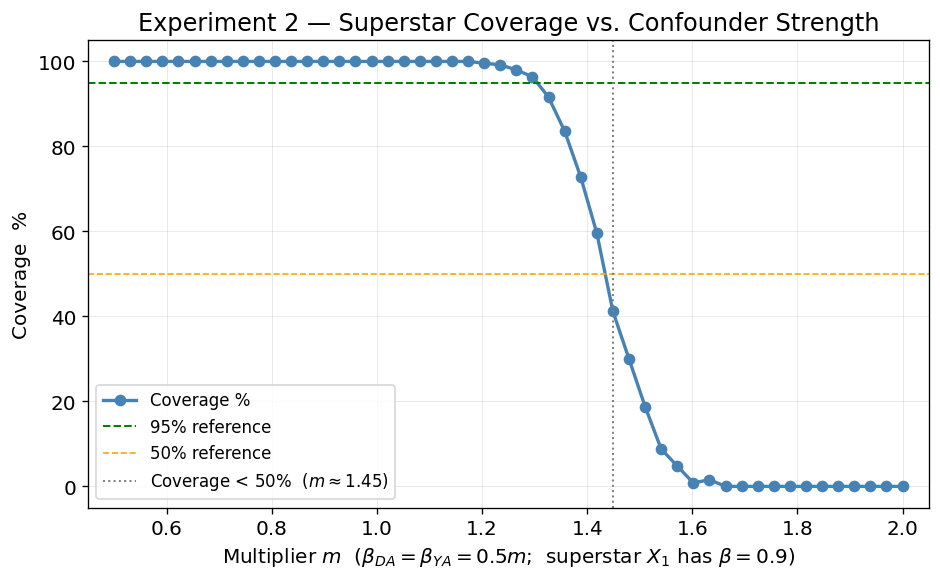

In [4]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, coverage, marker='o', linewidth=2, color='steelblue', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$;  superstar $X_1$ has $\beta=0.9$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 2 — Superstar Coverage vs. Confounder Strength')
ax.set_ylim(-5, 105)
ax.set_xlim(multipliers[0] - 0.05, multipliers[-1] + 0.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_coverage.png', bbox_inches='tight')
plt.show()

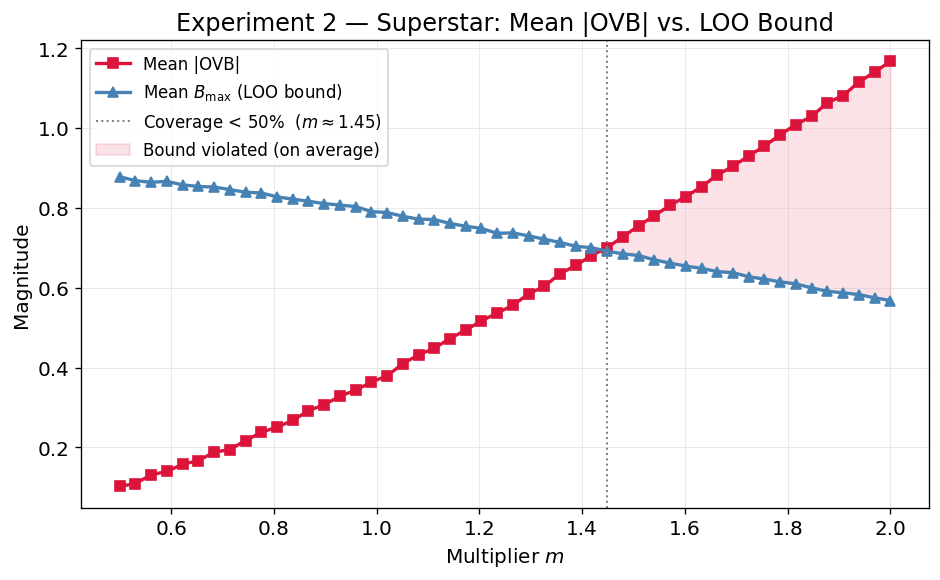

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',
        label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='steelblue',
        label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr),
                color='crimson', alpha=0.12, label='Bound violated (on average)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 2 — Superstar: Mean |OVB| vs. LOO Bound')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_ovb_vs_bound.png', bbox_inches='tight')
plt.show()

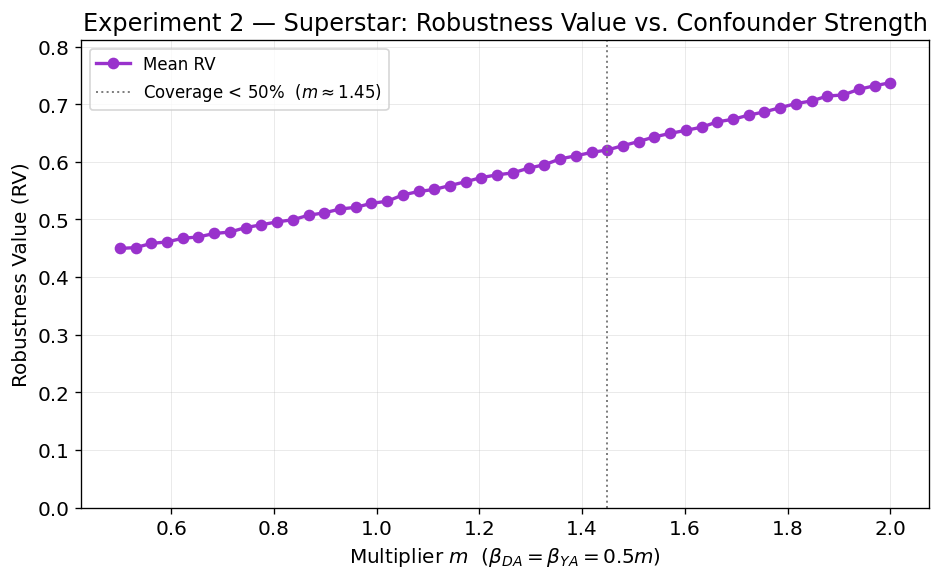

In [6]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_RV, marker='o', linewidth=2, color='darkorchid', label='Mean RV')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$)')
ax.set_ylabel('Robustness Value (RV)')
ax.set_title('Experiment 2 — Superstar: Robustness Value vs. Confounder Strength')
ax.set_ylim(0, max(mean_RV) * 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_rv.png', bbox_inches='tight')
plt.show()

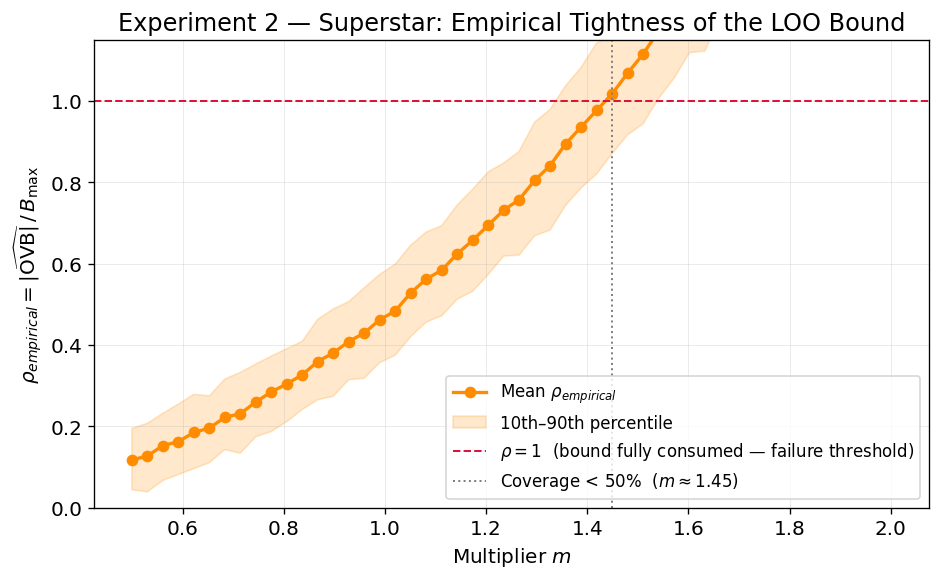

In [7]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_rho, marker='o', linewidth=2, color='darkorange',
        label=r'Mean $\rho_{empirical}$')
ax.fill_between(multipliers, p10_rho, p90_rho,
                alpha=0.2, color='darkorange', label='10th–90th percentile')
ax.axhline(1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = 1$  (bound fully consumed — failure threshold)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$\rho_{empirical} = |\widehat{\mathrm{OVB}}| \,/\, B_{\max}$')
ax.set_title('Experiment 2 — Superstar: Empirical Tightness of the LOO Bound')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_rho.png', bbox_inches='tight')
plt.show()

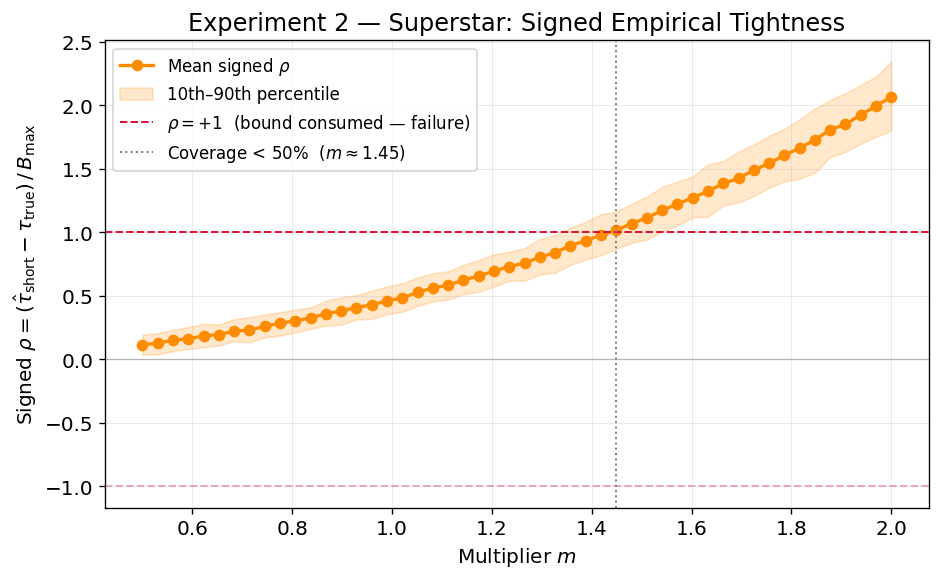

In [8]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_signed_rho, marker='o', linewidth=2, color='darkorange',
        label=r'Mean signed $\rho$')
ax.fill_between(multipliers, p10_signed_rho, p90_signed_rho,
                alpha=0.2, color='darkorange', label='10th–90th percentile')
ax.axhline( 1.0, linestyle='--', color='crimson', linewidth=1.2,
            label=r'$\rho = +1$  (bound consumed — failure)')
ax.axhline(-1.0, linestyle='--', color='crimson', linewidth=1.2, alpha=0.35)
ax.axhline( 0.0, linestyle='-',  color='gray',    linewidth=0.8, alpha=0.5)
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(
    r'Signed $\rho = (\hat{\tau}_{\mathrm{short}} - \tau_{\mathrm{true}}) \,/\, B_{\max}$'
)
ax.set_title('Experiment 2 — Superstar: Signed Empirical Tightness')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_signed_rho.png', bbox_inches='tight')
plt.show()

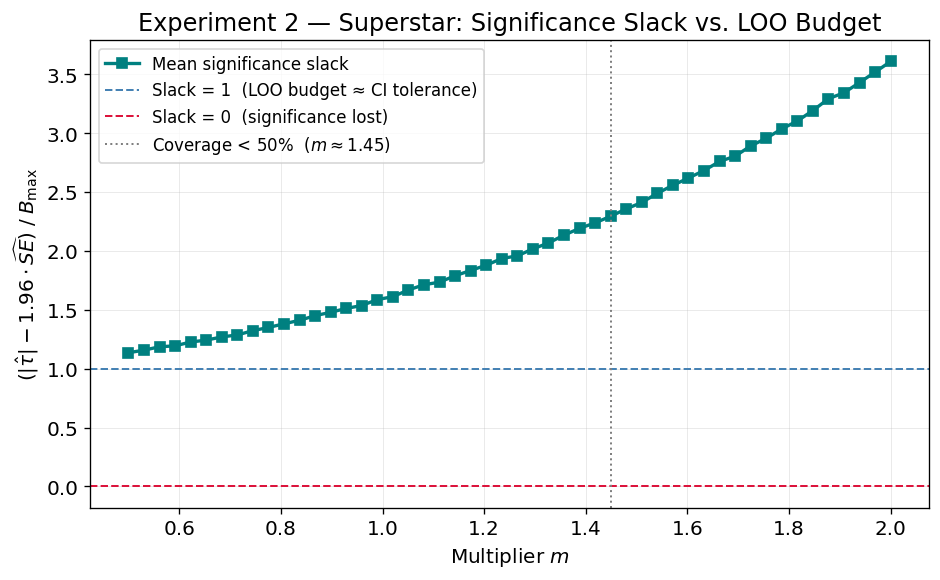

In [9]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_sig_slack, marker='s', linewidth=2, color='teal',
        label='Mean significance slack')
ax.axhline(1.0, linestyle='--', color='steelblue', linewidth=1.2,
           label='Slack = 1  (LOO budget ≈ CI tolerance)')
ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1.2,
           label='Slack = 0  (significance lost)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$(|\hat{\tau}| - 1.96 \cdot \widehat{SE}) \;/\; B_{\max}$')
ax.set_title('Experiment 2 — Superstar: Significance Slack vs. LOO Budget')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_sig_slack.png', bbox_inches='tight')
plt.show()

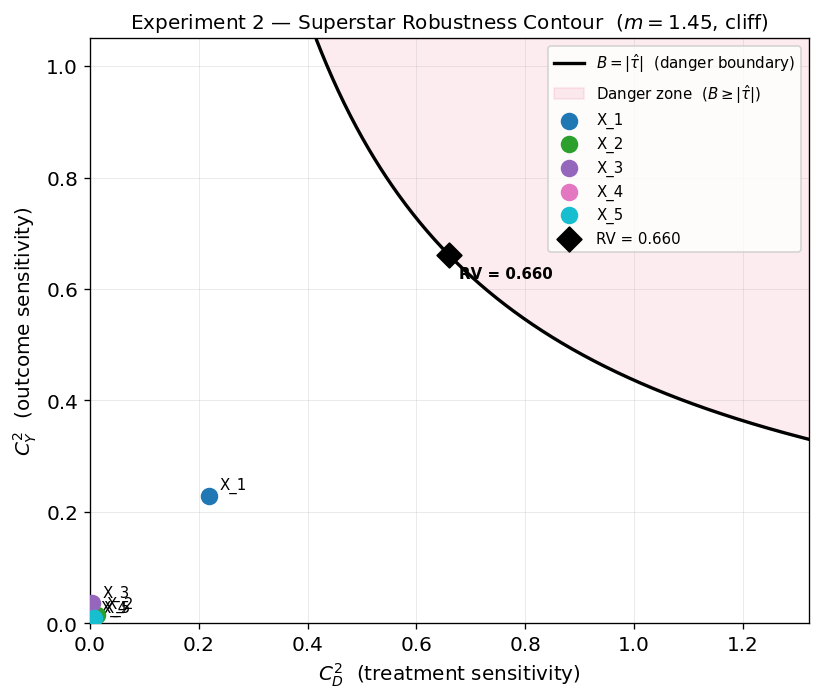

In [10]:
cliff_idx  = next((i for i, c in enumerate(coverage) if c < 50), len(multipliers) - 1)
cliff_m    = multipliers[cliff_idx]
tau_s, S2, loo_r = last_trial_data[cliff_idx]

fig, ax = plt.subplots(figsize=(7, 6))
plot_robustness_contour(
    tau_hat     = tau_s,
    S2          = S2,
    loo_results = loo_r,
    ax          = ax,
    title       = f'Experiment 2 — Superstar Robustness Contour  ($m = {cliff_m:.2f}$, cliff)',
)
plt.tight_layout()
plt.savefig('figures/experiment_02_superstar_contour.png', bbox_inches='tight')
plt.show()

In [11]:
import pandas as pd
from IPython.display import display

df_valid = pd.DataFrame({
    'Multiplier':   multipliers,
    'Coverage (%)': coverage,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
    'Mean ρ':       mean_rho,
    'p10 ρ':        p10_rho,
    'p90 ρ':        p90_rho,
    'R²(A|X)':      mean_r2_ax,
}).round(4)

print("Validity Diagnostics  (does the LOO bound cover the true OVB?)")
display(
    df_valid.style.format(precision=4)
    .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1)
    .background_gradient(subset=['Mean ρ'],       cmap='RdYlGn_r', vmin=0, vmax=2)
)

print()

df_prac = pd.DataFrame({
    'Multiplier':   multipliers,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Sig Slack':    mean_sig_slack,
}).round(4)

print("Practitioner View  (what the analyst sees — no knowledge of A)")
display(
    df_prac.style.format(precision=4)
    .background_gradient(subset=['Sig Slack'], cmap='RdYlGn', vmin=-1, vmax=3)
)

Validity Diagnostics  (does the LOO bound cover the true OVB?)


,Multiplier,Coverage (%),Bound Slack,Mean ρ,p10 ρ,p90 ρ,R²(A|X)
0,0.5000,100.0000,0.7761,0.1172,0.0439,0.1950,0.0024
1,0.5306,100.0000,0.7590,0.1273,0.0388,0.2075,0.0026
2,0.5612,100.0000,0.7330,0.1527,0.0670,0.2322,0.0026
3,0.5918,100.0000,0.7270,0.1625,0.0815,0.2549,0.0025
4,0.6224,100.0000,0.7000,0.1850,0.0961,0.2789,0.0024
5,0.6531,100.0000,0.6874,0.1959,0.1106,0.2750,0.0027
6,0.6837,100.0000,0.6642,0.2221,0.1428,0.3163,0.0027
7,0.7143,100.0000,0.6518,0.2312,0.1340,0.3328,0.0025
8,0.7449,100.0000,0.6224,0.2600,0.1744,0.3535,0.0024
9,0.7755,100.0000,0.6001,0.2848,0.1873,0.3726,0.0025



Practitioner View  (what the analyst sees — no knowledge of A)


,Multiplier,Mean |OVB|,Mean B_max,Sig Slack
0,0.5000,0.1021,0.8782,1.1355
1,0.5306,0.1094,0.8684,1.1574
2,0.5612,0.1313,0.8642,1.1860
3,0.5918,0.1397,0.8667,1.1941
4,0.6224,0.1579,0.8578,1.2266
5,0.6531,0.1665,0.8538,1.2425
6,0.6837,0.1882,0.8524,1.2697
7,0.7143,0.1942,0.8461,1.2866
8,0.7449,0.2170,0.8394,1.3233
9,0.7755,0.2375,0.8376,1.3499


## Interpretation

- **$m < \approx 1.3$ (safe zone):** $A$'s influence is weaker than even the weak $X_j$ covariates.
  The LOO bound comfortably covers the OVB.  Coverage ≈ 100%.

- **$m \approx 1.3$–$1.5$ (the cliff slope):** $A$ begins to outpace the weaker $X_j$'s but is
  still below the superstar $X_1$ (coefficient 0.9).  Because $B_{\max}$ is anchored to the
  *strongest* $X_j$, coverage erodes gradually rather than falling vertically — this is the
  "smooth cliff" effect of the superstar variable.

- **$m > \approx 1.5$ (past the cliff):** $A$'s partial $R^2$ exceeds what the superstar $X_1$
  can justify.  $B_{\max}$ is now too small to contain the OVB and coverage collapses to 0%.

### Cliff extension and budget amplification

The cliff at $m \approx 1.45$ is a **47% extension** over the baseline cliff at $m \approx 0.99$
(Experiment 1).  The protective effect is even clearer in the budget: $B_{\max}$ at $m = 0.5$ is
0.878 vs. 0.370 in Exp 1 — the superstar more than **doubles the LOO budget**.

### Why the cliff is earlier than the raw coefficient ratio

A naïve prediction from the coefficient ratio gives cliff at $0.9 / 0.5 = 1.8$; the observed
cliff is 1.45, roughly 20% earlier.  The gap arises because the bound is proportional to the
*product* of partial $R^2$ values — $C_Y^2 \cdot C_D^2 \cdot S^2$ — which grows quadratically
in confounder strength, while $B_{\max}$ scales only with the superstar's observed partial $R^2$.
The crossing condition is therefore set by the ratio of **squared** partial influences, a stricter
requirement than the raw coefficient ratio.  Concretely: the superstar's partial $R^2$ advantage
over $A$ erodes faster than the coefficient ratio suggests, and the cliff arrives sooner.

### Core limitation exposed

The LOO benchmark implicitly assumes the hidden confounder is *no more powerful* than the
strongest observed covariate (in partial $R^2$ terms).  Once $A$ crosses that threshold, the
bound provides no protection.

### Compare to Experiment 1 (baseline)

The cliff is shifted right relative to the equal-strength baseline, because the 0.9-coefficient
superstar keeps $B_{\max}$ elevated longer.  The gap between the two cliff locations is the
measurable protective effect of covariate imbalance — and it is larger than the coefficient
comparison alone would suggest.

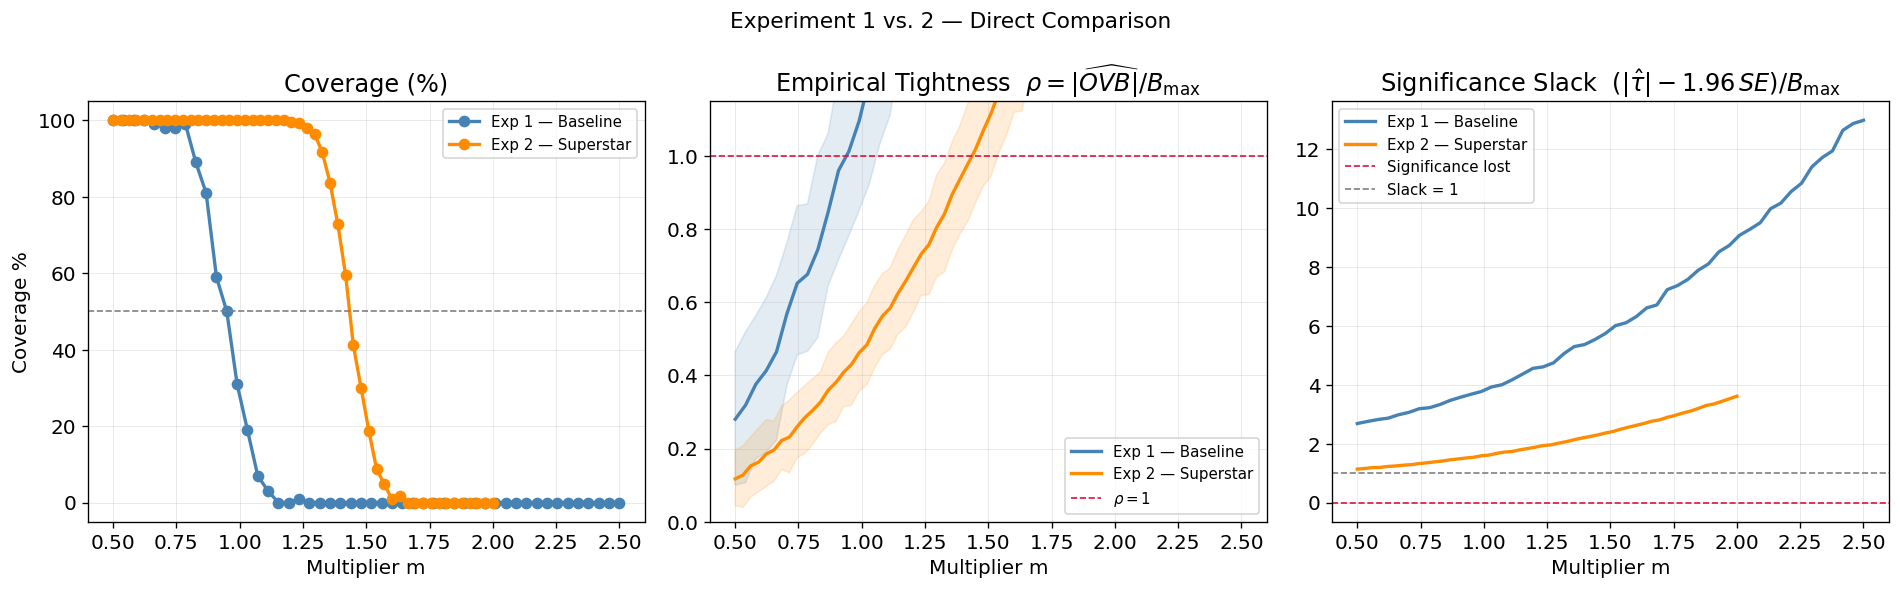

In [12]:
try:
    r1 = np.load('results/experiment_01_results.npy', allow_pickle=True).item()
    r2 = np.load('results/experiment_02_results.npy', allow_pickle=True).item()
except FileNotFoundError as e:
    print(f"Missing: {e} — run both experiment notebooks first.")
    r1 = r2 = None

if r1 is not None and r2 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Coverage
    ax = axes[0]
    ax.plot(r1['multipliers'], r1['coverage'], marker='o', linewidth=2,
            color='steelblue', label='Exp 1 — Baseline')
    ax.plot(r2['multipliers'], r2['coverage'], marker='o', linewidth=2,
            color='darkorange', label='Exp 2 — Superstar')
    ax.axhline(50, linestyle='--', color='gray', linewidth=1)
    ax.set_title('Coverage (%)')
    ax.set_xlabel('Multiplier m')
    ax.set_ylabel('Coverage %')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Empirical tightness with fan
    ax = axes[1]
    ax.plot(r1['multipliers'], r1['mean_rho'], linewidth=2,
            color='steelblue', label='Exp 1 — Baseline')
    ax.fill_between(r1['multipliers'], r1['p10_rho'], r1['p90_rho'],
                    alpha=0.15, color='steelblue')
    ax.plot(r2['multipliers'], r2['mean_rho'], linewidth=2,
            color='darkorange', label='Exp 2 — Superstar')
    ax.fill_between(r2['multipliers'], r2['p10_rho'], r2['p90_rho'],
                    alpha=0.15, color='darkorange')
    ax.axhline(1.0, linestyle='--', color='crimson', linewidth=1, label=r'$\rho = 1$')
    ax.set_title(r'Empirical Tightness  $\rho = |\widehat{OVB}| / B_{\max}$')
    ax.set_xlabel('Multiplier m')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Significance slack
    ax = axes[2]
    ax.plot(r1['multipliers'], r1['mean_sig_slack'], linewidth=2,
            color='steelblue', label='Exp 1 — Baseline')
    ax.plot(r2['multipliers'], r2['mean_sig_slack'], linewidth=2,
            color='darkorange', label='Exp 2 — Superstar')
    ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1, label='Significance lost')
    ax.axhline(1.0, linestyle='--', color='gray', linewidth=1, label='Slack = 1')
    ax.set_title(r'Significance Slack  $(|\hat{\tau}| - 1.96\,SE) / B_{\max}$')
    ax.set_xlabel('Multiplier m')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Experiment 1 vs. 2 — Direct Comparison', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/experiment_comparison.png', bbox_inches='tight')
    plt.show()